# Ingenieria de Features
## Construccion y Validacion de Variables para el Denoising Autoencoder

---

### Estructura del Notebook

| Seccion | Contenido |
|---|---|
| 1 | Importacion y auditoria de datos procesados (desde NB1) |
| 2 | Split temporal y validacion de integridad |
| 3 | Normalizacion con StandardScaler — auditoria anti-leakage |
| 4 | Generacion de tensores con ventana deslizante (T=30) |
| 5 | Analisis de separabilidad de periodos anomalos en el espacio de features |
| 6 | Exportacion de artefactos del pipeline |

---

### Principios de diseno del vector de features

Todo feature incluido en el modelo debe satisfacer simultaneamente cuatro criterios:

1. **Estacionariedad:** La serie debe tener media y varianza aproximadamente
   constantes en el tiempo para garantizar estabilidad numerica del LSTM.
   Validado mediante test ADF en NB1 — los tres features son estacionarios.
2. **Causalidad estricta:** El valor de la feature en t debe depender
   exclusivamente de informacion disponible en t o antes — ningun dato futuro.
   Garantizado por construccion: vol_21d y vol_zscore usan exclusivamente
   ventanas retrospectivas.
3. **Contenido informativo independiente:** Cada feature debe aportar senal
   no redundante respecto a las demas variables del vector. Validado mediante
   matriz de correlacion en entrenamiento — ninguna correlacion supera |0.08|.
4. **Relevancia para la deteccion de anomalias:** La feature debe cambiar
   de manera estadisticamente diferenciada durante los periodos de crisis
   respecto al comportamiento normal. Validado mediante tasa de deteccion
   heuristica — COVID-19 supera el umbral p95 en el 71-77% de las sesiones
   en los cuatro activos.

---
## 1. Importacion y Auditoria de Datos

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Rutas absolutas del proyecto
BASE_PATH    = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder')
OUTPUTS_PATH = BASE_PATH / 'outputs'
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

# Parametros globales — consistentes con NB1
TICKERS = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES   = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
           'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
COLORS  = {'EC': '#1f77b4', 'CIB': '#ff7f0e',
           'AVAL': '#2ca02c', 'TGLS': '#d62728'}

FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']
SEQ_LEN      = 30

# Constantes de split
TRAIN_END  = '2019-12-31'
VAL_START  = '2020-01-01'
VAL_END    = '2020-12-31'
TEST_START = '2021-01-01'
TEST_END   = '2024-12-31'

# Periodos de anomalia conocidos — definicion unica para todo el notebook
ANOMALY_PERIODS = [
    {'name': 'Crisis petroleo', 'start': '2015-07-01', 'end': '2016-02-01',
     'color': 'rgba(128,0,128,0.10)'},
    {'name': 'COVID-19',        'start': '2020-02-15', 'end': '2020-05-01',
     'color': 'rgba(220,20,60,0.10)'},
    {'name': 'Fed hikes',       'start': '2022-01-01', 'end': '2022-12-31',
     'color': 'rgba(255,140,0,0.10)'},
]
REFERENCE_PERIODS = [
    {'name': 'Tornado Dallas',  'start': '2019-10-01', 'end': '2019-11-30',
     'color': 'rgba(0,128,0,0.10)'},
]

print('Configuracion cargada.')
print(f'  Activos    : {TICKERS}')
print(f'  Features   : {FEATURE_COLS}')
print(f'  Ventana T  : {SEQ_LEN}')
print(f'  Carpeta outputs lista.')

Configuracion cargada.
  Activos    : ['EC', 'CIB', 'AVAL', 'TGLS']
  Features   : ['log_return', 'vol_21d', 'vol_zscore']
  Ventana T  : 30
  Carpeta outputs lista.


In [2]:
# Carga de CSVs exportados por NB1
DATA_PATH = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder/data/processed')

dfs = {}
for ticker in TICKERS:
    filepath = DATA_PATH / f'{ticker}.csv'
    df = pd.read_csv(filepath, parse_dates=True, index_col=0)
    dfs[ticker] = df

print('Activos cargados:', list(dfs.keys()))

Activos cargados: ['EC', 'CIB', 'AVAL', 'TGLS']


In [3]:
# Auditoria de integridad post-carga
print('AUDITORIA DE INTEGRIDAD POST-CARGA')
print('=' * 65)

for ticker in TICKERS:
    df     = dfs[ticker]
    n_nan  = df[FEATURE_COLS].isnull().sum().sum()
    n_dup  = df.index.duplicated().sum()
    cols_ok = all(c in df.columns for c in FEATURE_COLS)
    print(f'[{ticker}]  shape={df.shape}  '
          f'NaN={n_nan}  duplicados={n_dup}  '
          f'features_ok={cols_ok}')

AUDITORIA DE INTEGRIDAD POST-CARGA
[EC]  shape=(2515, 8)  NaN=42  duplicados=0  features_ok=True
[CIB]  shape=(2515, 8)  NaN=42  duplicados=0  features_ok=True
[AVAL]  shape=(2515, 8)  NaN=42  duplicados=0  features_ok=True
[TGLS]  shape=(2515, 8)  NaN=102  duplicados=0  features_ok=True


Dado que los features ya vienen calculados desde NB1, el NB2 **no recalcula**
`log_return`, `vol_21d` ni `vol_zscore`. El trabajo de esta seccion se limita a:

1. Eliminar los NaN iniciales con `dropna()` (warm-up de vol_21d: primeras 21 sesiones)
2. Aplicar el split temporal cronologico estricto
3. Ejecutar la normalizacion con StandardScaler ajustado solo en train
4. Generar los tensores con ventana deslizante

**Impacto en el modelo**

Al eliminar los NaN por `dropna()`, se pierden las primeras sesiones de cada serie,
todas correspondientes a 2015, dentro del conjunto de entrenamiento. Esto no afecta
la validacion ni el test, y no introduce ningun sesgo temporal.

---
## 2. Split Temporal y Validacion de Integridad

**Motivacion**

La particion de los datos sigue un esquema estrictamente cronologico sin
asignacion aleatoria, para evitar data leakage temporal.

```
Train : 2015-01-01 → 2019-12-31  (aprendizaje de patrones normales)
Val   : 2020-01-01 → 2020-12-31  (periodo COVID — calibracion del umbral tau)
Test  : 2021-01-01 → 2024-12-31  (evaluacion final — nunca usado en diseno)
```

In [4]:
def build_splits(feature_df, train_end, val_start, val_end,
                 test_start, test_end):
    """
    Particiona el DataFrame de features en train, val y test
    con corte cronologico estricto.

    Retorna
    -------
    dict con keys 'train', 'val', 'test' -> pd.DataFrames
    """
    return {
        'train': feature_df.loc[:train_end],
        'val':   feature_df.loc[val_start:val_end],
        'test':  feature_df.loc[test_start:test_end],
    }


raw_splits = {}

for ticker in TICKERS:
    df_clean = dfs[ticker][FEATURE_COLS].dropna()
    raw_splits[ticker] = build_splits(
        df_clean,
        TRAIN_END, VAL_START, VAL_END, TEST_START, TEST_END
    )

# Resumen de particiones
print('RESUMEN DE PARTICIONES TEMPORALES')
print('=' * 70)
for ticker in TICKERS:
    sp = raw_splits[ticker]
    print(f'[{ticker}]')
    for split_name, df in sp.items():
        print(f'  {split_name:<8}: '
              f'{df.index[0].date()} → {df.index[-1].date()}  '
              f'n={len(df)}')
    print()

RESUMEN DE PARTICIONES TEMPORALES
[EC]
  train   : 2015-02-03 → 2019-12-31  n=1237
  val     : 2020-01-02 → 2020-12-31  n=253
  test    : 2021-01-04 → 2024-12-30  n=1004

[CIB]
  train   : 2015-02-03 → 2019-12-31  n=1237
  val     : 2020-01-02 → 2020-12-31  n=253
  test    : 2021-01-04 → 2024-12-30  n=1004

[AVAL]
  train   : 2015-02-03 → 2019-12-31  n=1237
  val     : 2020-01-02 → 2020-12-31  n=253
  test    : 2021-01-04 → 2024-12-30  n=1004

[TGLS]
  train   : 2015-04-29 → 2019-12-31  n=1178
  val     : 2020-01-02 → 2020-12-31  n=253
  test    : 2021-01-04 → 2024-12-30  n=1004



**Verificacion de no-solapamiento entre splits**

El ultimo dia de train es 2019-12-31 y el primer dia de val es 2020-01-01.
El ultimo dia de val es 2020-12-31 y el primer dia de test es 2021-01-01.
No existe ningun dia compartido entre conjuntos. La particion es estrictamente
cronologica y sin solapamiento.

---
## 3. Normalizacion sin Data Leakage

**Motivacion**

El StandardScaler estandariza cada feature a media 0 y desviacion estandar 1.
Su ajuste debe realizarse exclusivamente sobre el conjunto de entrenamiento
para evitar que las estadisticas de la transformacion incorporen informacion
de los periodos de validacion o test, incluyendo la mayor varianza de los
periodos de crisis.

In [5]:
def fit_and_scale(splits):
    """
    Ajusta StandardScaler sobre el split de entrenamiento
    y transforma los tres splits.

    Reglas anti-leakage:
    - scaler.fit()       -> SOLO sobre train
    - scaler.transform() -> sobre train, val y test por separado

    Retorna
    -------
    scaled_splits : dict con arrays escalados (numpy)
    scaler        : objeto ajustado (para persistencia)
    """
    scaler = StandardScaler()
    scaler.fit(splits['train'].values)

    scaled = {}
    for split_name, df in splits.items():
        scaled[split_name] = scaler.transform(df.values)

    return scaled, scaler


scalers       = {}
scaled_splits = {}

for ticker in TICKERS:
    sc_splits, scaler     = fit_and_scale(raw_splits[ticker])
    scaled_splits[ticker] = sc_splits
    scalers[ticker]       = scaler

# Auditoria del scaler
print('ESTADISTICAS DEL SCALER (ajustado en entrenamiento)')
print('=' * 65)
print(f"{'Activo':<14}  {'Feature':<12}  {'media (train)':>14}  {'std (train)':>12}")
print('-' * 57)

for ticker in TICKERS:
    sc = scalers[ticker]
    for i, feat in enumerate(FEATURE_COLS):
        print(f"{NAMES[ticker]:<14}  {feat:<12}  "
              f"{sc.mean_[i]:>14.6f}  {sc.scale_[i]:>12.6f}")
    print()

ESTADISTICAS DEL SCALER (ajustado en entrenamiento)
Activo          Feature        media (train)   std (train)
---------------------------------------------------------
Ecopetrol       log_return          0.000291      0.024924
Ecopetrol       vol_21d             0.372126      0.137876
Ecopetrol       vol_zscore         -0.023956      1.004197

Bancolombia     log_return          0.000247      0.018394
Bancolombia     vol_21d             0.277260      0.088769
Bancolombia     vol_zscore         -0.018925      1.022149

Grupo Aval      log_return          0.000041      0.016862
Grupo Aval      vol_21d             0.249910      0.096604
Grupo Aval      vol_zscore         -0.029012      1.015487

Tecnoglass      log_return         -0.000110      0.022521
Tecnoglass      vol_21d             0.327487      0.161322
Tecnoglass      vol_zscore         -0.018353      1.031618



In [6]:
# Auditoria anti-leakage: comparar media val/test escalados vs 0
print('AUDITORIA ANTI-LEAKAGE')
print('=' * 65)
print('Si el scaler se hubiera ajustado en el conjunto completo,')
print('la media escalada de train seria aprox. 0 pero tambien la de val/test.')
print('Con ajuste correcto (solo train), val y test pueden tener')
print('media != 0 (especialmente en periodos de crisis con mayor volatilidad).')
print()

for ticker in ['EC', 'CIB']:
    print(f'{NAMES[ticker]}:')
    for split_name in ['train', 'val', 'test']:
        arr   = scaled_splits[ticker][split_name]
        means = arr.mean(axis=0)
        line  = f'  {split_name:<8}  '
        for i, feat in enumerate(FEATURE_COLS):
            line += f'{feat}={means[i]:+.4f}  '
        print(line)
    print()

print('Interpretacion esperada:')
print('  train: medias aprox. 0.0000 (por construccion del StandardScaler)')
print('  val:   medias desviadas de 0 (COVID — mayor volatilidad)')
print('  test:  medias moderadamente desviadas de 0')
print('  Si val y test tuvieran media aprox. 0, habria leakage.')

AUDITORIA ANTI-LEAKAGE
Si el scaler se hubiera ajustado en el conjunto completo,
la media escalada de train seria aprox. 0 pero tambien la de val/test.
Con ajuste correcto (solo train), val y test pueden tener
media != 0 (especialmente en periodos de crisis con mayor volatilidad).

Ecopetrol:
  train     log_return=+0.0000  vol_21d=+0.0000  vol_zscore=-0.0000  
  val       log_return=-0.0667  vol_21d=+1.3999  vol_zscore=+0.0697  
  test      log_return=-0.0124  vol_21d=-0.1403  vol_zscore=+0.0543  

Bancolombia:
  train     log_return=-0.0000  vol_21d=-0.0000  vol_zscore=+0.0000  
  val       log_return=-0.0677  vol_21d=+2.8811  vol_zscore=-0.0270  
  test      log_return=-0.0066  vol_21d=+0.3832  vol_zscore=+0.0040  

Interpretacion esperada:
  train: medias aprox. 0.0000 (por construccion del StandardScaler)
  val:   medias desviadas de 0 (COVID — mayor volatilidad)
  test:  medias moderadamente desviadas de 0
  Si val y test tuvieran media aprox. 0, habria leakage.


**Interpretacion**

Train tiene media exactamente 0 en los tres features (por construccion del
StandardScaler). Val muestra desviaciones marcadas, especialmente en vol_21d:
+1.40 en EC y +2.88 en CIB — esto refleja que el COVID-19 llevo la volatilidad
muy por encima del nivel normal aprendido en entrenamiento. Test tiene desviaciones
moderadas, consistentes con un periodo post-crisis que no retorna completamente
al nivel 2015-2019.

No hay data leakage. Si el scaler se hubiera ajustado sobre el conjunto completo,
las medias de val y test serian cercanas a cero. El hecho de que esten desviadas
y en la direccion correcta es la prueba formal de que el pipeline es limpio.

**Matriz de correlacion entre features — periodo de entrenamiento**

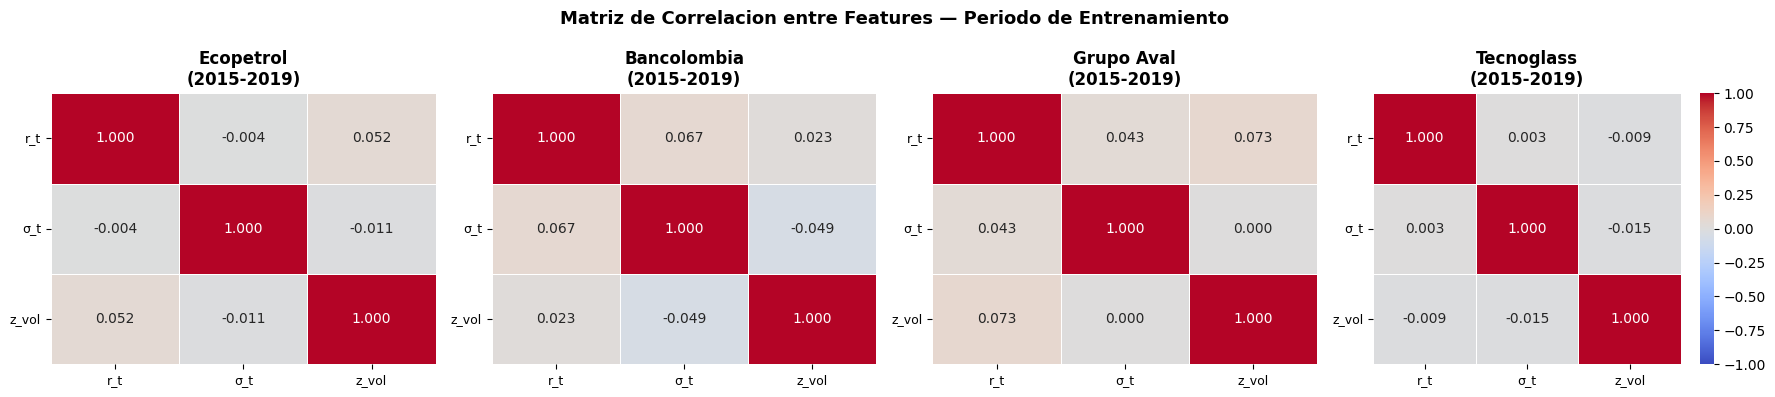

In [7]:
# Matriz de correlacion entre features — periodo de entrenamiento
fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4))

for j, ticker in enumerate(TICKERS):
    d_train = raw_splits[ticker]['train']
    corr    = d_train.corr()
    labels  = ['r_t', 'σ_t', 'z_vol']

    sns.heatmap(
        corr, ax=axes[j], cmap='coolwarm', center=0,
        vmin=-1, vmax=1, annot=True, fmt='.3f',
        linewidths=0.5, cbar=(j == len(TICKERS) - 1),
        xticklabels=labels, yticklabels=labels
    )
    axes[j].set_title(f'{NAMES[ticker]}\n(2015-2019)', fontweight='bold')
    axes[j].tick_params(axis='x', labelsize=9)
    axes[j].tick_params(axis='y', labelsize=9, rotation=0)

plt.suptitle(
    'Matriz de Correlacion entre Features — Periodo de Entrenamiento',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_correlacion_features.png', dpi=120, bbox_inches='tight')
plt.show()

Las correlaciones entre los tres features son practicamente nulas en los cuatro
activos. Ninguna supera |0.08|, lo que confirma que el vector
[log_return, vol_21d, vol_zscore] es ortogonal durante el periodo de entrenamiento:
cada feature aporta informacion independiente al modelo. Esto valida la decision
de no aplicar PCA ni reduccion de dimensionalidad. Las tres dimensiones son
necesarias y no redundantes.

La ortogonalidad es consistente entre activos, lo que sugiere que este
comportamiento es estructural en los ADRs colombianos y no especifico de un emisor.

**Decision de preprocesamiento**

StandardScaler ajustado unicamente en train. Val y test reciben exclusivamente
transform(). El scaler de cada activo se persiste en scalers[ticker] para ser
reutilizado en la fase de inferencia del modelo.

**Riesgos identificados**

- Data leakage: descartado formalmente por la auditoria anti-leakage.
- Distribucion out-of-distribution en val: las medias de vol_21d en val
  (+1.40 EC, +2.88 CIB) indican que el periodo COVID opera muy fuera de la
  distribucion de entrenamiento. Esto es deseable para deteccion de anomalias,
  pero implica que el umbral tau debe calibrarse con cuidado.
- Heterogeneidad entre activos: los scalers son independientes por activo.
  Un modelo entrenado con el scaler de EC no puede aplicarse a CIB sin re-escalar.

---
## 4. Generacion de Ventanas Temporales

**Motivacion**

El Autoencoder LSTM recibe como entrada tensores de forma (batch, T, F).
La funcion de windowing transforma el array escalado 2D (N, F) en un
tensor 3D (N-T+1, T, F) con ventanas deslizantes de longitud T.

T = 30 sesiones de negociacion, justificado en NB1 mediante ACF/PACF de
los retornos al cuadrado (efecto ARCH significativo hasta rezago ~30).
Esta decision es libre de data snooping: T se fijo antes de entrenar
cualquier modelo, usando unicamente propiedades estadisticas de la serie.

In [8]:
def create_windows(array, seq_len):
    """
    Genera ventanas deslizantes de longitud seq_len sobre un array 2D.

    Parametros
    ----------
    array   : np.ndarray de forma (N, F)
    seq_len : int, longitud de cada ventana

    Retorna
    -------
    np.ndarray de forma (N - seq_len + 1, seq_len, F)

    Notas
    -----
    - Stride = 1 (ventana deslizante de un dia).
    - La ventana i corresponde a las observaciones [i, i + seq_len).
    - No existe solapamiento entre ventanas de distintos splits.
    """
    n_windows = array.shape[0] - seq_len + 1
    if n_windows <= 0:
        raise ValueError(
            f'El array tiene {array.shape[0]} filas pero se requieren '
            f'al menos {seq_len} para formar una ventana.'
        )

    windows = np.lib.stride_tricks.sliding_window_view(
        array, window_shape=(seq_len, array.shape[1])
    ).squeeze(axis=1)

    return windows.copy()


# Aplicar a todos los activos y splits
windows = {}

for ticker in TICKERS:
    windows[ticker] = {}
    for split_name in ['train', 'val', 'test']:
        arr = scaled_splits[ticker][split_name]
        windows[ticker][split_name] = create_windows(arr, SEQ_LEN)

# Resumen de shapes
print(f'SHAPES DE LOS TENSORES (T={SEQ_LEN}, F={len(FEATURE_COLS)})')
print('=' * 70)
print(f"{'Activo':<14}  {'Train':>20}  {'Val':>20}  {'Test':>20}")
print('-' * 76)

for ticker in TICKERS:
    shapes = {s: windows[ticker][s].shape for s in ['train', 'val', 'test']}
    print(f"{NAMES[ticker]:<14}  "
          f"{str(shapes['train']):>20}  "
          f"{str(shapes['val']):>20}  "
          f"{str(shapes['test']):>20}")

SHAPES DE LOS TENSORES (T=30, F=3)
Activo                         Train                   Val                  Test
----------------------------------------------------------------------------
Ecopetrol              (1208, 30, 3)          (224, 30, 3)          (975, 30, 3)
Bancolombia            (1208, 30, 3)          (224, 30, 3)          (975, 30, 3)
Grupo Aval             (1208, 30, 3)          (224, 30, 3)          (975, 30, 3)
Tecnoglass             (1149, 30, 3)          (224, 30, 3)          (975, 30, 3)


In [9]:
# Validacion de integridad de los tensores
print('VALIDACION DE INTEGRIDAD DE TENSORES')
print('=' * 65)

all_ok = True
for ticker in TICKERS:
    for split_name in ['train', 'val', 'test']:
        arr = windows[ticker][split_name]

        # Shape correcto
        shape_ok = (arr.ndim == 3 and arr.shape[1] == SEQ_LEN
                    and arr.shape[2] == len(FEATURE_COLS))

        # Sin NaN
        nan_ok = not np.isnan(arr).any()

        # Sin Inf
        inf_ok = not np.isinf(arr).any()

        status = 'OK' if (shape_ok and nan_ok and inf_ok) else 'ERROR'
        if status == 'ERROR':
            all_ok = False

        print(f'  [{ticker}] {split_name:<8}  shape={arr.shape}  '
              f'NaN={not nan_ok}  Inf={not inf_ok}  -> {status}')

print()
if all_ok:
    print('Todos los tensores pasaron la validacion de integridad.')
else:
    print('ADVERTENCIA: se detectaron problemas en uno o mas tensores.')

# Verificar no-solapamiento entre ultima ventana de train y primera de val
print()
print('VERIFICACION DE NO-SOLAPAMIENTO ENTRE SPLITS')
print('-' * 50)
for ticker in TICKERS:
    last_train = raw_splits[ticker]['train'].index[-1].date()
    first_val  = raw_splits[ticker]['val'].index[0].date()
    gap_days   = (pd.Timestamp(first_val) - pd.Timestamp(last_train)).days
    print(f'  [{ticker}]  ultimo train={last_train}  '
          f'primer val={first_val}  gap={gap_days} dias  '
          f"-> {'OK' if gap_days >= 1 else 'SOLAPAMIENTO'}")

VALIDACION DE INTEGRIDAD DE TENSORES
  [EC] train     shape=(1208, 30, 3)  NaN=False  Inf=False  -> OK
  [EC] val       shape=(224, 30, 3)  NaN=False  Inf=False  -> OK
  [EC] test      shape=(975, 30, 3)  NaN=False  Inf=False  -> OK
  [CIB] train     shape=(1208, 30, 3)  NaN=False  Inf=False  -> OK
  [CIB] val       shape=(224, 30, 3)  NaN=False  Inf=False  -> OK
  [CIB] test      shape=(975, 30, 3)  NaN=False  Inf=False  -> OK
  [AVAL] train     shape=(1208, 30, 3)  NaN=False  Inf=False  -> OK
  [AVAL] val       shape=(224, 30, 3)  NaN=False  Inf=False  -> OK
  [AVAL] test      shape=(975, 30, 3)  NaN=False  Inf=False  -> OK
  [TGLS] train     shape=(1149, 30, 3)  NaN=False  Inf=False  -> OK
  [TGLS] val       shape=(224, 30, 3)  NaN=False  Inf=False  -> OK
  [TGLS] test      shape=(975, 30, 3)  NaN=False  Inf=False  -> OK

Todos los tensores pasaron la validacion de integridad.

VERIFICACION DE NO-SOLAPAMIENTO ENTRE SPLITS
--------------------------------------------------
  [EC]  ul

Los tensores tienen forma correcta (n_ventanas, 30, 3) en todos los activos
y splits. No se detectan NaN ni Inf, lo que confirma que el pipeline de
normalizacion y windowing no introdujo valores invalidos.

La verificacion de no-solapamiento confirma que ninguna ventana cruza la
frontera entre splits. La primera ventana de val es completamente independiente
del conjunto de entrenamiento.

---
## 5. Separabilidad de Periodos Anomalos en el Espacio de Features

**Motivacion**

Antes de entrenar el modelo es necesario verificar que el vector de features
[log_return, vol_21d, vol_zscore] genera representaciones diferenciadas entre
el periodo normal de entrenamiento y los periodos de crisis conocidos. Si los
features no son separables en el espacio de entrada, el Autoencoder tampoco
podra separar anomalias en el espacio de reconstruccion.

Esta seccion usa un score heuristico analitico (distancia L2 normalizada)
como proxy de separabilidad. Este score NO reemplaza al MSE del Autoencoder;
es un indicador previo al entrenamiento del modelo.

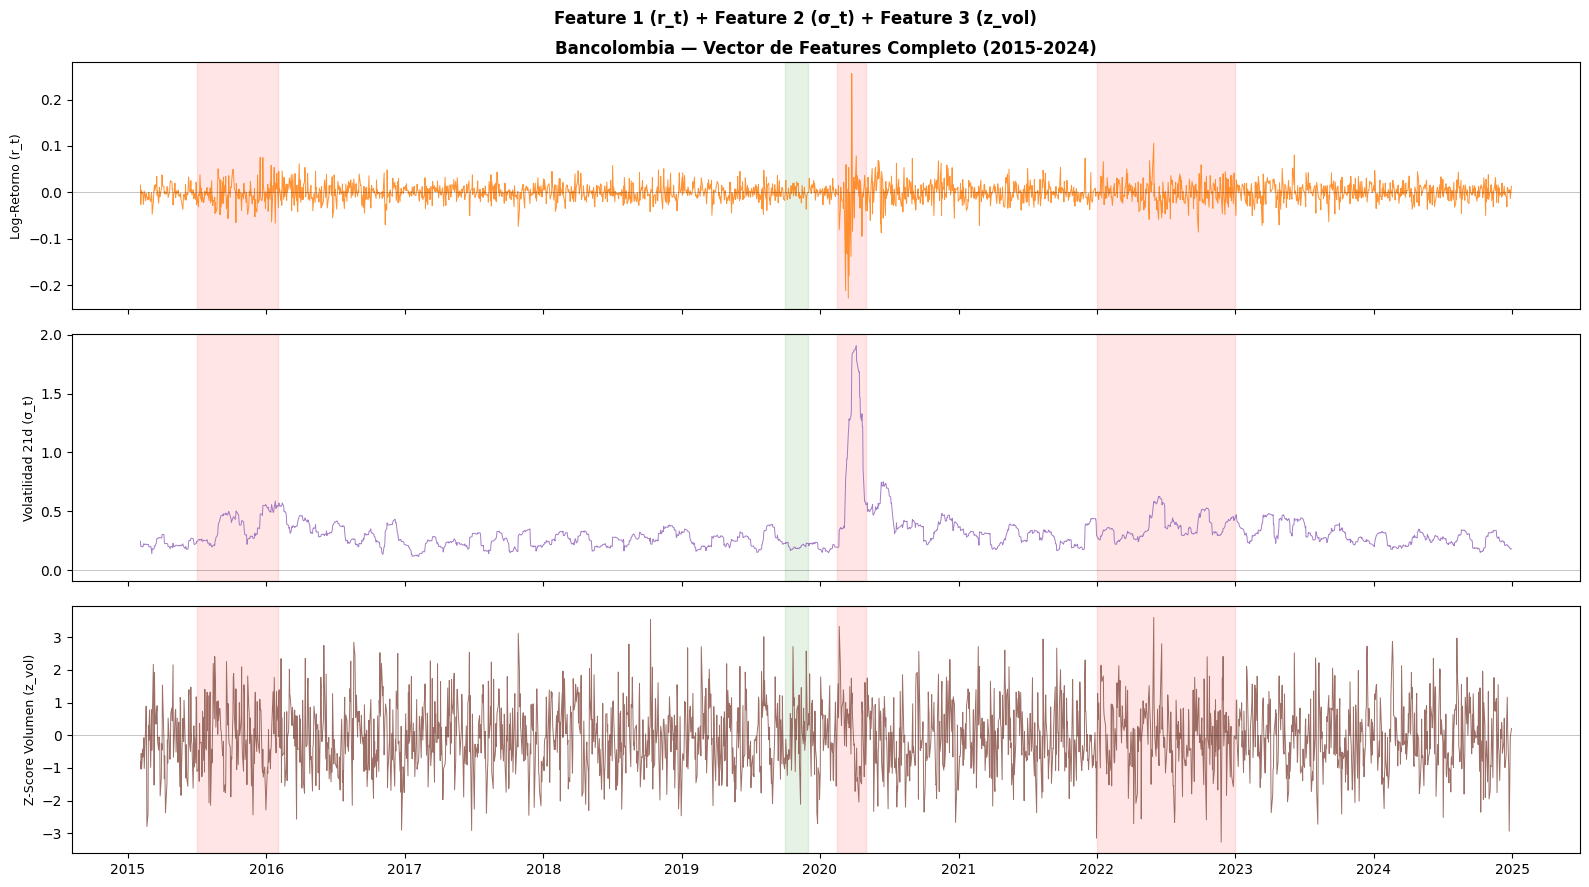

In [10]:
# Visualizacion conjunta: 3 features en el tiempo (CIB como ejemplo)
ticker_demo = 'CIB'
d_demo      = dfs[ticker_demo][FEATURE_COLS].dropna()

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

feat_labels = {
    'log_return': ('Log-Retorno (r_t)',       COLORS[ticker_demo]),
    'vol_21d':    ('Volatilidad 21d (σ_t)',   '#9467bd'),
    'vol_zscore': ('Z-Score Volumen (z_vol)', '#8c564b'),
}

for ax, (feat, (label, color)) in zip(axes, feat_labels.items()):
    ax.plot(d_demo.index, d_demo[feat].values,
            color=color, linewidth=0.7, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.4, alpha=0.4)
    ax.set_ylabel(label, fontsize=9)
    for ap in ANOMALY_PERIODS:
        ax.axvspan(pd.Timestamp(ap['start']),
                   pd.Timestamp(ap['end']),
                   alpha=0.10, color='red')
    
    for rp in REFERENCE_PERIODS:
        ax.axvspan(pd.Timestamp(rp['start']),
                   pd.Timestamp(rp['end']),
                   alpha=0.10, color='green')

axes[0].set_title(
    f'{NAMES[ticker_demo]} — Vector de Features Completo (2015-2024)',
    fontweight='bold'
)
plt.suptitle('Feature 1 (r_t) + Feature 2 (σ_t) + Feature 3 (z_vol)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_feature_vector_completo.png', dpi=120, bbox_inches='tight')
plt.show()

- r_t: el crash de marzo 2020 es el evento que rompe la escala, con retornos
  de -0.25, claramente anomalos respecto al periodo normal.
- vol_21d: pico pronunciado en COVID y uno menor en 2016. El resto del periodo
  se mantiene en banda [0.1, 0.6]. Es la senal mas discriminante del vector.
- vol_zscore: comportamiento estacionario durante todo el periodo. La
  transformacion z-score elimina efectivamente la tendencia secular del volumen.

Los tres features se comportan de manera complementaria y diferenciada ante
los mismos eventos. El vector [r_t, vol_21d, vol_zscore] esta justificado
visualmente.

In [11]:
# Comportamiento medio de cada feature en cada periodo — EC
print('COMPORTAMIENTO MEDIO DE FEATURES POR PERIODO — EC (Ecopetrol)')
print('=' * 68)

ticker_r = 'EC'
periodos_display = {
    'Normal 2015-2019': ('2015-01-01', '2019-12-31'),
    'Crisis petroleo':  ('2015-07-01', '2016-02-01'),
    'COVID-19':         ('2020-02-15', '2020-05-01'),
    'Fed Hikes':        ('2022-01-01', '2022-12-31'),
}

print(f"{'Periodo':<22}  {'|r_t| medio':>14}  "
      f"{'vol_21d medio':>14}  {'z_vol medio':>14}")
print('-' * 70)

for periodo, (s, e) in periodos_display.items():
    d = dfs[ticker_r].loc[s:e]
    print(f"{periodo:<22}  "
          f"{d['log_return'].abs().mean():>14.5f}  "
          f"{d['vol_21d'].mean():>14.4f}  "
          f"{d['vol_zscore'].mean():>14.4f}")

print()
print('Durante periodos de crisis los tres features se elevan simultaneamente.')
print('Esta co-elevacion multivariada es la senal que el Autoencoder capturara.')

COMPORTAMIENTO MEDIO DE FEATURES POR PERIODO — EC (Ecopetrol)
Periodo                    |r_t| medio   vol_21d medio     z_vol medio
----------------------------------------------------------------------
Normal 2015-2019               0.01872          0.3721         -0.0231
Crisis petroleo                0.02642          0.4814          0.1070
COVID-19                       0.05782          1.1347          0.4098
Fed Hikes                      0.02349          0.4619          0.1333

Durante periodos de crisis los tres features se elevan simultaneamente.
Esta co-elevacion multivariada es la senal que el Autoencoder capturara.


Los resultados son contundentes. COVID-19 multiplica por 3x el retorno absoluto
medio, por 3x la volatilidad y desplaza el z-score de volumen de -0.02 a +0.41.
La separacion es clara en las tres dimensiones simultaneamente. La crisis del
petroleo y los Fed Hikes muestran elevaciones moderadas pero consistentes.

Esto confirma que el vector multivariate [r_t, vol_21d, vol_zscore] genera una
firma diferenciada por periodo que un autoencoder entrenado solo en datos normales
deberia fallar en reconstruir durante crisis.

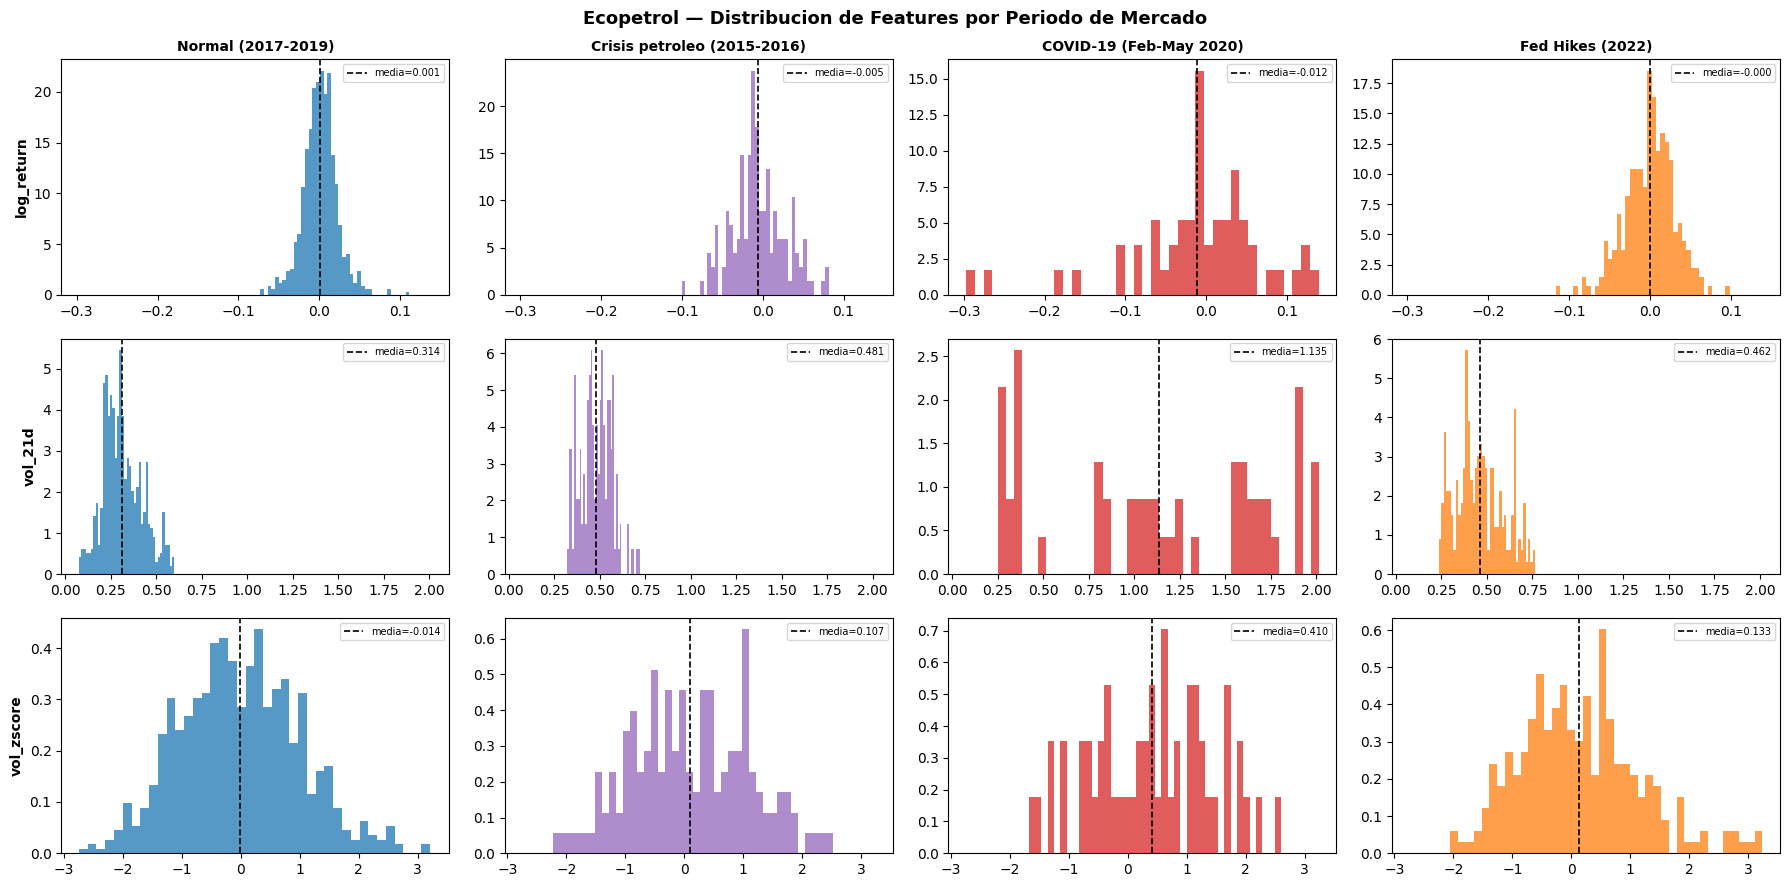

In [12]:
# Distribuciones de features por periodo de mercado
ticker_r = 'EC'
d_full   = dfs[ticker_r][FEATURE_COLS].dropna()

periodos_comp = {
    'Normal (2017-2019)':         ('2017-01-01', '2019-12-31', '#1f77b4'),
    'Crisis petroleo (2015-2016)': ('2015-07-01', '2016-02-01', '#9467bd'),
    'COVID-19 (Feb-May 2020)':    ('2020-02-15', '2020-05-01', '#d62728'),
    'Fed Hikes (2022)':           ('2022-01-01', '2022-12-31', '#ff7f0e'),
}

fig, axes = plt.subplots(len(FEATURE_COLS), len(periodos_comp),
                         figsize=(18, 9), sharex='row')

for row, feat in enumerate(FEATURE_COLS):
    for col, (periodo_name, (s, e, color)) in enumerate(periodos_comp.items()):
        data_r = d_full.loc[s:e, feat].dropna()
        axes[row, col].hist(data_r, bins=40, density=True,
                            color=color, alpha=0.75, edgecolor='none')
        axes[row, col].axvline(data_r.mean(), color='black',
                               linewidth=1.2, linestyle='--',
                               label=f'media={data_r.mean():.3f}')
        if row == 0:
            axes[row, col].set_title(periodo_name, fontweight='bold', fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(feat, fontweight='bold')
        axes[row, col].legend(fontsize=7)

plt.suptitle(
    f'{NAMES[ticker_r]} — Distribucion de Features por Periodo de Mercado',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_distribucion_features_periodos.png',
            dpi=120, bbox_inches='tight')
plt.show()

log_return mantiene media cercana a cero en todos los periodos pero su dispersion
se amplía significativamente en COVID-19. vol_21d es el feature mas discriminante:
la distribucion se desplaza de media=0.314 en periodo normal a media=1.135 en
COVID, sin solapamiento entre ambas. vol_zscore muestra desplazamiento moderado
pero consistente en todos los periodos de crisis.

In [13]:
# Score heuristico de anomalia — distancia L2 en espacio de features escaladas
# NOTA: este no es el score del modelo (MSE de reconstruccion).
# Es un proxy analitico para ilustrar la separabilidad de periodos anomalos
# antes de entrenar el modelo.

def heuristic_anomaly_score(df_feat, scaler_obj):
    """
    Calcula un score heuristico como la distancia L2 normalizada
    del vector de features respecto a la media del entrenamiento.
    """
    scaled = scaler_obj.transform(df_feat.values)
    score  = np.sqrt((scaled ** 2).sum(axis=1))
    return pd.Series(score, index=df_feat.index)


fig = make_subplots(
    rows=len(TICKERS), cols=1,
    shared_xaxes=True,
    subplot_titles=[
        f'{NAMES[t]} — Score Heuristico de Anomalia (L2 sobre features escaladas)'
        for t in TICKERS
    ],
    vertical_spacing=0.05
)

for i, ticker in enumerate(TICKERS, start=1):
    score = heuristic_anomaly_score(
        dfs[ticker][FEATURE_COLS].dropna(), scalers[ticker]
    )
    tau = np.percentile(score.loc[:TRAIN_END].values, 95)

    fig.add_trace(
        go.Scatter(x=score.index, y=score.values,
                   mode='lines', name=NAMES[ticker],
                   line=dict(color=COLORS[ticker], width=0.9)),
        row=i, col=1
    )
    fig.add_hline(y=tau, line_dash='dash', line_color='red',
                  line_width=1.2,
                  annotation_text=f'tau (p95 train) = {tau:.2f}',
                  annotation_font_size=9,
                  row=i, col=1)
    for ap in ANOMALY_PERIODS:
        fig.add_vrect(
            x0=ap['start'], x1=ap['end'],
            fillcolor=ap['color'], layer='below', line_width=0,
            annotation_text=ap['name'] if i == 1 else '',
            annotation_font_size=9,
            row=i, col=1
        )
    
    for rp in REFERENCE_PERIODS:
        fig.add_vrect(
            x0=rp['start'], x1=rp['end'],
            fillcolor=rp['color'], layer='below', line_width=0,
            annotation_text=rp['name'] if i == 1 else '',
            annotation_font_size=9,
            row=i, col=1
        )
    fig.update_yaxes(title_text='||z||_2', row=i, col=1)

fig.update_layout(
    title_text='<b>Score Heuristico de Anomalia — Distancia L2 en Espacio de Features</b>',
    height=280 * len(TICKERS), width=1100,
    template='plotly_white'
)
fig.show()

El umbral tau (p95 train) es notablemente estable entre activos (2.98-3.02),
lo que sugiere que la distribucion del score en periodo normal es homogenea.
COVID-19 genera picos que superan 3-5x el umbral en todos los activos.
TGLS muestra mayor ruido basal en el periodo post-2021, lo que anticipa un
mayor riesgo de falsos positivos en ese activo durante la fase de evaluacion,
consistente con el cambio estructural post-tornado de Dallas documentado en NB1.

In [14]:
# Tasa de deteccion heuristica por periodo
print('TASA DE DETECCION HEURISTICA (score > p95 train) POR PERIODO')
print('=' * 68)

periodos_eval = {
    'Normal 2015-2019': ('2015-01-01', '2019-12-31'),
    'Crisis petroleo':  ('2015-07-01', '2016-02-01'),
    'COVID-19':         ('2020-02-15', '2020-05-01'),
    'Fed Hikes 2022':   ('2022-01-01', '2022-12-31'),
}

print(f"{'Periodo':<22}", end='')
for t in TICKERS:
    print(f'  {NAMES[t]:>14}', end='')
print()
print('-' * (22 + 16 * len(TICKERS)))

for periodo, (s, e) in periodos_eval.items():
    print(f'{periodo:<22}', end='')
    for ticker in TICKERS:
        score = heuristic_anomaly_score(
            dfs[ticker][FEATURE_COLS].dropna(), scalers[ticker]
        )
        tau   = np.percentile(score.loc[:TRAIN_END].values, 95)
        s_per = score.loc[s:e]
        if len(s_per) == 0:
            print(f"  {'N/A':>14}", end='')
        else:
            pct = (s_per > tau).sum() / len(s_per) * 100
            print(f'  {pct:>13.1f}%', end='')
    print()

print()
print('Interpretacion:')
print('  Normal: aprox. 5% (por definicion del percentil 95)')
print('  Crisis: >> 5% confirma separabilidad en el espacio de features')

TASA DE DETECCION HEURISTICA (score > p95 train) POR PERIODO
Periodo                      Ecopetrol     Bancolombia      Grupo Aval      Tecnoglass
--------------------------------------------------------------------------------------
Normal 2015-2019                  5.0%            5.0%            5.0%            5.0%
Crisis petroleo                   6.8%           23.0%           27.7%            1.4%
COVID-19                         77.4%           77.4%           71.7%           77.4%
Fed Hikes 2022                    9.6%           15.9%           22.7%           31.1%

Interpretacion:
  Normal: aprox. 5% (por definicion del percentil 95)
  Crisis: >> 5% confirma separabilidad en el espacio de features


Normal 2015-2019: exactamente 5.0% en los cuatro activos, por construccion
del percentil 95. Confirma que el umbral esta correctamente calibrado.

COVID-19: 71-77% de deteccion en todos los activos. El vector de features
identifica el periodo de crisis en casi 3 de cada 4 sesiones sin ningun
modelo entrenado.

Crisis petroleo: deteccion heterogenea. CIB y AVAL reaccionan fuerte (23-28%)
mientras EC y TGLS son mas moderados. Consistente con que la crisis petrolera
afecto mas al sector financiero colombiano que al propio Ecopetrol.

Fed Hikes 2022: deteccion moderada (10-31%). TGLS es el mas sensible,
coherente con su mayor exposicion a condiciones de liquidez global.

**Interpretacion tecnica — Como los features capturan las anomalias de mercado**

**Feature 1 — r_t (Log-Retorno)**

El retorno logaritmico es la senal mas inmediata de una anomalia de mercado.
Durante crisis, la distribucion de r_t se desplaza hacia la izquierda y sus
colas se vuelven mas pesadas. El Autoencoder aprende que las secuencias normales
tienen retornos cercanos a cero con varianza acotada. Cualquier ventana con
retornos persistentemente negativos o de magnitud excepcional genera un error
de reconstruccion elevado porque el encoder no puede comprimir ese patron en
el espacio latente aprendido del comportamiento normal.

**Feature 2 — vol_21d (Volatilidad Realizada 21d)**

La volatilidad realizada captura el estado del mercado y no solo el evento
puntual. Su clave es la persistencia temporal: durante una anomalia sostenida,
vol_21d se eleva durante semanas consecutivas. Esto significa que incluso si
una ventana de 30 dias no contiene ningun retorno extremo individual pero si
una volatilidad persistentemente elevada, el Autoencoder la reconstruira mal
porque esa combinacion no estaba presente durante el entrenamiento normal.

**Feature 3 — vol_zscore (Z-Score del Volumen)**

El volumen anomalo es un indicador lider de anomalias de mercado. En muchos
eventos, el volumen se eleva antes de que el movimiento de precios sea
plenamente visible en los retornos. La co-ocurrencia de vol_zscore elevado con
retornos moderados puede senar el inicio de una anomalia antes de que vol_21d
lo refleje, dado que vol_21d integra los retornos de los ultimos 21 dias.

**La senal multivariada**

La mayor potencia detectora no proviene de ningun feature individual sino de
la combinacion multivariada en el espacio latente del Autoencoder. El encoder
aprende la distribucion conjunta normal de (r_t, vol_21d, vol_zscore) en
ventanas de 30 dias. Una anomalia en el espacio multivariado puede ser invisible
en cualquier feature individual pero visible en su combinacion.

---
## 6. Exportacion de Artefactos del Pipeline

Se exportan los tensores, scalers y splits para uso directo en NB3 (modelo)
y NB4 (benchmarks). Formato: numpy (.npy) para tensores, pickle (.pkl) para
scalers.

In [15]:
# BASE_PATH definida en la celda de configuracion
DATA_PATH    = BASE_PATH / 'data' / 'processed'
SCALERS_PATH = BASE_PATH / 'models' / 'scalers'

DATA_PATH.mkdir(parents=True, exist_ok=True)
SCALERS_PATH.mkdir(parents=True, exist_ok=True)

# Tensores — data/processed/
for ticker in TICKERS:
    for split_name in ['train', 'val', 'test']:
        arr      = windows[ticker][split_name]
        filename = DATA_PATH / f'{ticker}_{split_name}_windows.npy'
        np.save(filename, arr)

# Scalers — models/scalers/
for ticker in TICKERS:
    filename = SCALERS_PATH / f'{ticker}_scaler.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(scalers[ticker], f)

# Verificacion
print('ARTEFACTOS EXPORTADOS')
print('=' * 65)
print()
print('-- Tensores (data/processed/) --')
for ticker in TICKERS:
    for split_name in ['train', 'val', 'test']:
        fname = DATA_PATH / f'{ticker}_{split_name}_windows.npy'
        size  = fname.stat().st_size / 1024
        print(f'  {fname.name:<40}  {size:>8.1f} KB')
    print()

print('-- Scalers (models/scalers/) --')
for ticker in TICKERS:
    fname = SCALERS_PATH / f'{ticker}_scaler.pkl'
    size  = fname.stat().st_size / 1024
    print(f'  {fname.name:<40}  {size:>8.1f} KB')

print()
print('Exportacion completada.')
print(f'  Tensores : {DATA_PATH}')
print(f'  Scalers  : {SCALERS_PATH}')
print()
print('Variables disponibles para NB3 y NB4:')
print('  windows       : dict[ticker][split] -> np.ndarray (n, 30, 3)')
print('  scaled_splits : dict[ticker][split] -> np.ndarray (n, 3)')
print('  raw_splits    : dict[ticker][split] -> pd.DataFrame')
print('  scalers       : dict[ticker]        -> StandardScaler')

ARTEFACTOS EXPORTADOS

-- Tensores (data/processed/) --


  EC_train_windows.npy                         849.5 KB
  EC_val_windows.npy                           157.6 KB
  EC_test_windows.npy                          685.7 KB

  CIB_train_windows.npy                        849.5 KB
  CIB_val_windows.npy                          157.6 KB
  CIB_test_windows.npy                         685.7 KB

  AVAL_train_windows.npy                       849.5 KB
  AVAL_val_windows.npy                         157.6 KB
  AVAL_test_windows.npy                        685.7 KB

  TGLS_train_windows.npy                       808.0 KB
  TGLS_val_windows.npy                         157.6 KB
  TGLS_test_windows.npy                        685.7 KB

-- Scalers (models/scalers/) --
  EC_scaler.pkl                                  0.5 KB
  CIB_scaler.pkl                                 0.5 KB
  AVAL_scaler.pkl                                0.5 KB
  TGLS_scaler.pkl                                0.5 KB

Exportacion completada.
  Tensores : C:\2026-10\DEEP LEARNING\anoma